In [1]:
import numpy as np
from astropy import units as u, constants as const
from matplotlib import pyplot as plt
import sys, os
sys.path.append('../simplify')
sys.path.append('../')
import importlib, lf_model, lf_optimizer, lf_plotter, utils, mass_function
importlib.reload(mass_function)
importlib.reload(utils)
importlib.reload(lf_model)
importlib.reload(lf_optimizer)
importlib.reload(lf_plotter)
from lf_model import *
from lf_plotter import LFPlotter
from lf_optimizer import run_optimize, LFOptimizer
#importlib.reload(collapse)
utils.my_mpl()
import matplotlib.cm as cm
import scipy.signal as sps

import colossus
from colossus.cosmology import cosmology
import colossus.lss.mass_function as cmf
from astropy.cosmology import z_at_value
from scipy.special import jv
from scipy.special import gamma as Gamma
import scipy.optimize as opt
import scipy

from astropy import constants as const, units as u

utils.my_mpl()
from scipy.interpolate import interp1d

from labellines import labelLine, labelLines

In [2]:
utils.my_mpl()

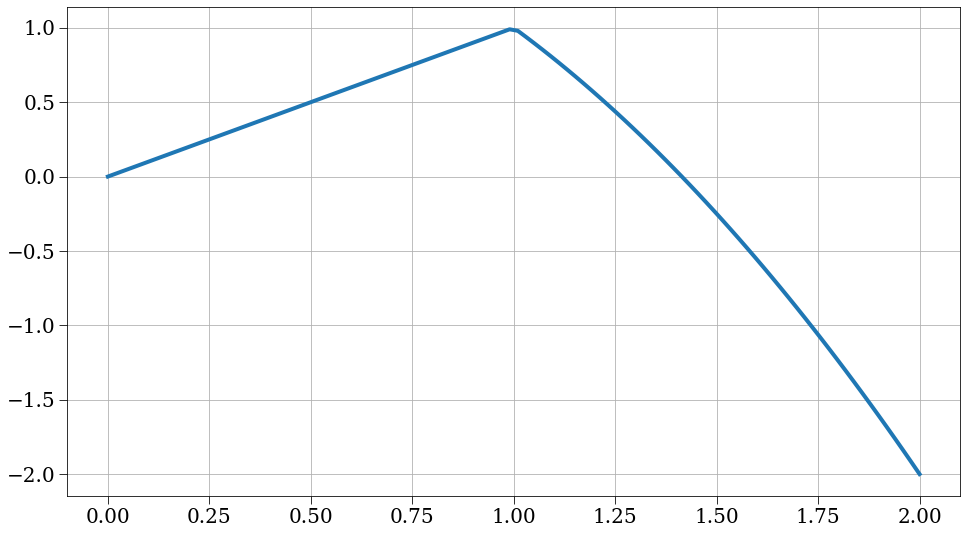

In [12]:
def y(x):
    if x <= 1:
        return x
    else:
        return -x**2 + 2
xvals = np.linspace(0, 2, 100)
yvals =[y(x) for x in xvals]
plt.plot(xvals, yvals)

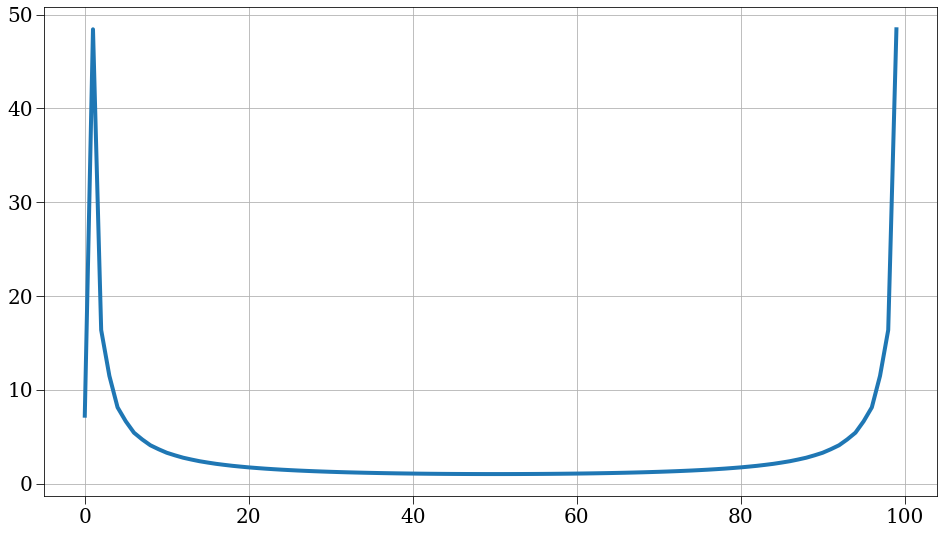

In [14]:
y2 = scipy.fft(yvals)
plt.plot(np.abs(y2))

In [5]:
Z_EQ = z_at_value(lambda z: utils.COSMO.Om(z) - utils.COSMO.Ogamma(z) - utils.COSMO.Onu(z), 0, zmin=3000, zmax=5000)
A_EQ = 1/(1+Z_EQ)
print(Z_EQ, f'{A_EQ:.2e}')

3386.84530529963 2.95e-04


/home/jsipple/.conda/envs/jsipple/lib/python3.7/site-packages/scipy/optimize/optimize.py:1969: RuntimeWarning: overflow encountered in double_scalars
  if ((p > tmp2 * (a - x)) and (p < tmp2 * (b - x)) and
/home/jsipple/.conda/envs/jsipple/lib/python3.7/site-packages/scipy/optimize/optimize.py:1961: RuntimeWarning: overflow encountered in double_scalars
  p = (x - v) * tmp2 - (x - w) * tmp1
/home/jsipple/.conda/envs/jsipple/lib/python3.7/site-packages/scipy/optimize/optimize.py:1961: RuntimeWarning: invalid value encountered in double_scalars
  p = (x - v) * tmp2 - (x - w) * tmp1
/home/jsipple/.conda/envs/jsipple/lib/python3.7/site-packages/scipy/optimize/optimize.py:1970: RuntimeWarning: overflow encountered in double_scalars
  (numpy.abs(p) < numpy.abs(0.5 * tmp2 * dx_temp))):


In [30]:
def k_tilde(k, m22=1):
    retval = np.sqrt(const.hbar) * k*u.Mpc**(-1) / np.sqrt(m22 * 10**-22 * u.eV * (1/const.c**2) * utils.H0)
    return retval.decompose()

def fdm_growth(z, k, m22=1, taylor=None):
    a = 1/(1+z)
    k_scaled = k_tilde(k,m22)
    if taylor is None:
        return a**(-1/4) * jv(-5/2, k_scaled**2 * a**(-1/2))
    else:
        return a**(-1/4) * np.sqrt(2/np.pi) * 3/(k_scaled**2 * a**(-1/2))**(5/2)

def gf(z, normalized=True):
    prefactor = 5*utils.OMEGA_M*utils.COSMO.H(z)/(2*utils.H0)  
    def integrand(z_prime): return (1+z_prime) / \
        (utils.COSMO.H(z_prime)/utils.H0)**3
    integral = utils.trapz_integrate(integrand, z, 2*Z_EQ, logspace=False, n_intervals=100000)
    retval = prefactor * integral
    if normalized:
        retval = retval / gf(z=0, normalized=False)
    return retval

def gf_matdom(z, z_norm=Z_EQ):
    return gf(z=z_norm, normalized=True) * (1+z_norm)/(1+z)


In [13]:
def func(k):
    return (k_tilde(k=k) - 1)**2
res = opt.minimize_scalar(func)
xline = res.x

In [14]:
print(f'{gf(Z_EQ):.1e}')

1.3e-04


In [15]:
fdm_growth(z=Z_EQ,k=1e-2)

<Quantity 5.2278866e+15>

In [3]:
def log_prior(inv_m22):
    m22 = 1/inv_m22
    logm = np.log10(m22)
    if logm >= -1 and logm <= 2:
        return m22/np.log(10) * 1/3
    return 0
def inv_prior(inv_m22):
    if inv_m22 > 0 and inv_m22 < 2:
        return 1/2
def jeff_prior(inv_m22):
    arr = np.load('../simplify/jefferys_prior_inv.npz')
    prior, inv_vals = arr['prior'], arr['inv_m22s']
    prior_interp = interp1d(inv_vals, prior, fill_value='extrapolate')
    prior_volume = utils.trapz_integrate(prior_interp, 0, 30)
    return prior_interp(inv_m22) #/ prior_volume
def jeff_prior_in_log(inv_m22):
    arr = np.load('../simplify/jefferys_prior_logspace.npz')
    prior, log_vals = arr['prior'], arr['logvals']
    prior_interp = interp1d(log_vals, prior, fill_value='extrapolate')
    prior_volume = utils.trapz_integrate(prior_interp, -5, 7)
    prior_interp = interp1d(log_vals, prior*(10**log_vals)/np.log(10), fill_value='extrapolate')
    m22 = 1/inv_m22
    logm = np.log10(m22)

    return prior_interp(logm) #/ prior_volume

def jeff_prior_in_log2(log_m22):
    arr = np.load('../simplify/jefferys_prior_logspace.npz')
    prior, log_vals = arr['prior'], arr['logvals']
    prior_interp = interp1d(log_vals, prior, fill_value='extrapolate')
    prior_volume = utils.trapz_integrate(prior_interp, -5, 7)
    prior_interp = interp1d(log_vals, prior*(10**log_vals)/np.log(10), fill_value='extrapolate')

    return prior_interp(log_m22) #/ prior_volume

0.08922296393463702


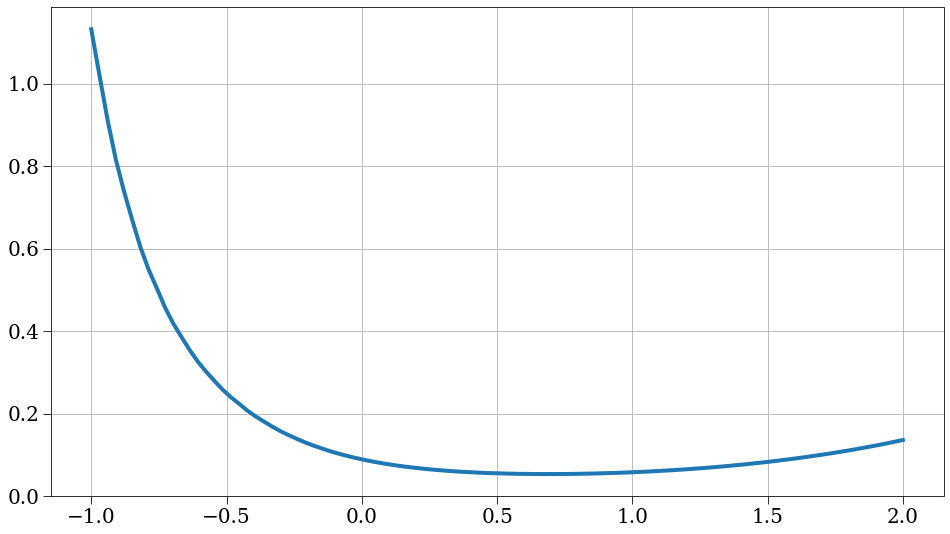

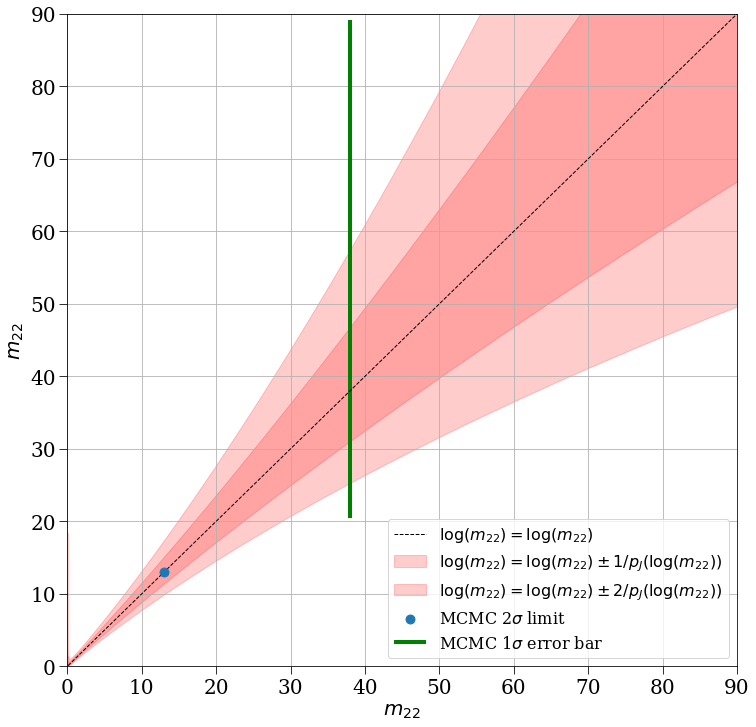

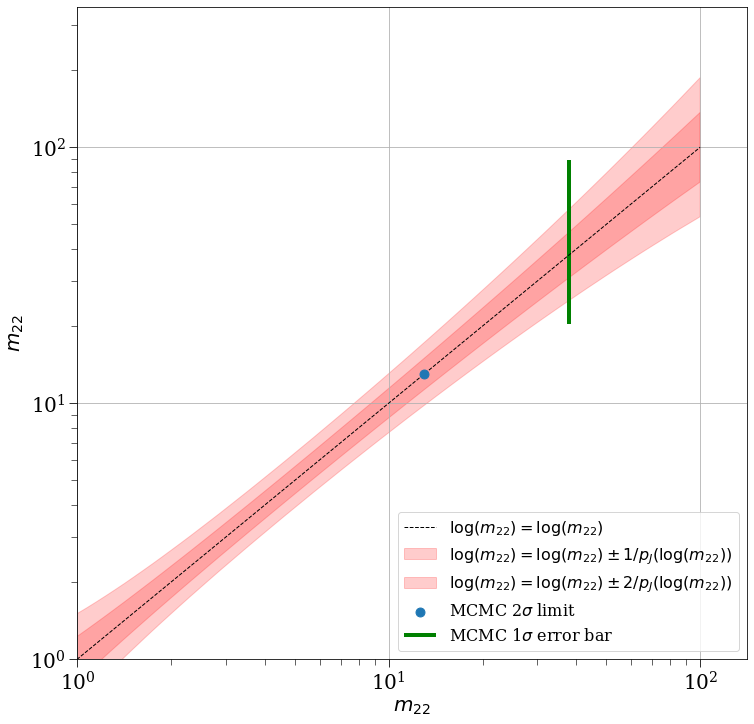

In [53]:
logm = np.linspace(-1,2,100)
sigma_tilde = np.array([1/jeff_prior_in_log2(lm) for lm in logm])
plt.plot(logm, sigma_tilde) 
print(1/jeff_prior_in_log2(1.58))
plt.figure(figsize=[12,12])
plt.plot(10**logm, 10**logm, color='k', ls='--', lw=1,label=r'$\log(m_{22})=\log(m_{22})$')
plt.fill_between(10**logm, 10**(logm+sigma_tilde), 10**(logm-sigma_tilde), color='red', alpha=0.2, label=r'$\log(m_{22})=\log(m_{22})\pm 1/p_J(\log(m_{22}))$')
plt.fill_between(10**logm, 10**(logm+2*sigma_tilde), 10**(logm-2*sigma_tilde), color='red', alpha=0.2, label=r'$\log(m_{22})=\log(m_{22})\pm 2/p_J(\log(m_{22}))$')
plt.scatter(13,13, zorder=99, s=80, label=r'MCMC 2$\sigma$ limit')
#plt.axhline(y=10**1.58, color='green')
#plt.axvline(x=10**1.58, color='green')
plt.vlines([10**1.58], [10**(1.58+0.37)], [10**(1.58-0.27)], color='green', alpha=1, label=r'MCMC 1$\sigma$ error bar')


plt.xlabel(r'$m_{22}$')
plt.ylabel(r'$m_{22}$')
plt.xlim(0,90)
plt.ylim(0,90)
plt.legend(loc='lower right', fontsize=16)

plt.figure(figsize=[12,12])
plt.plot(10**logm, 10**logm, color='k', ls='--', lw=1,label=r'$\log(m_{22})=\log(m_{22})$')
plt.fill_between(10**logm, 10**(logm+sigma_tilde), 10**(logm-sigma_tilde), color='red', alpha=0.2, label=r'$\log(m_{22})=\log(m_{22})\pm 1/p_J(\log(m_{22}))$')
plt.fill_between(10**logm, 10**(logm+2*sigma_tilde), 10**(logm-2*sigma_tilde), color='red', alpha=0.2, label=r'$\log(m_{22})=\log(m_{22})\pm 2/p_J(\log(m_{22}))$')
plt.scatter(13,13, zorder=99, s=80, label=r'MCMC 2$\sigma$ limit')
#plt.axhline(y=10**1.58, color='green')
#plt.axvline(x=10**1.58, color='green')
plt.vlines([10**1.58], [10**(1.58+0.37)], [10**(1.58-0.27)], color='green', alpha=1, label=r'MCMC 1$\sigma$ error bar')


plt.xlabel(r'$m_{22}$')
plt.ylabel(r'$m_{22}$')
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e0,None)
plt.ylim(1e0,None)
plt.legend(loc='lower right', fontsize=16)

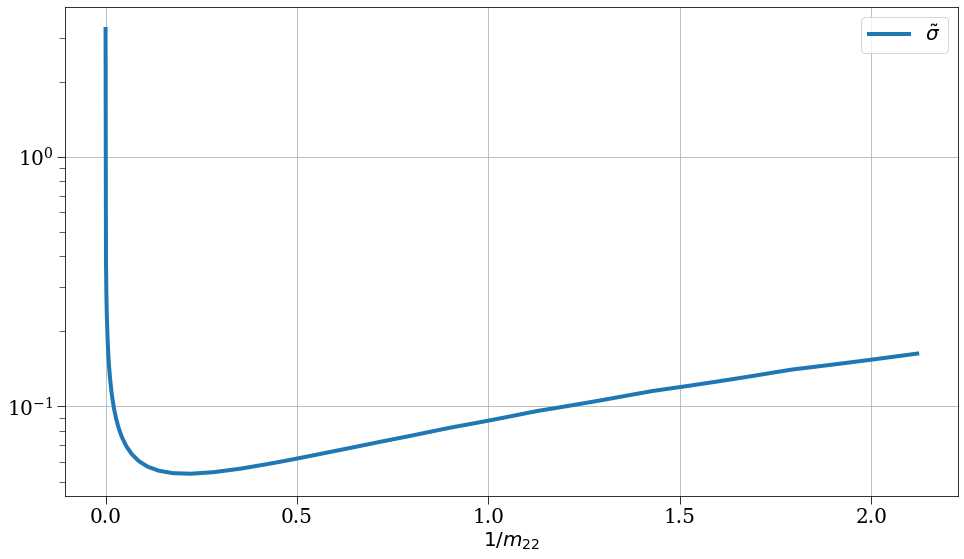

In [9]:
inv_m22 = np.linspace(1e-5,2.12,2000)
plt.plot(inv_m22, [1/jeff_prior(i) for i in inv_m22], label=r'$\tilde\sigma$')
plt.xlabel(r'$1/m_{22}$')
plt.yscale('log')
plt.legend()

Text(0.5, 0, '$m_{22}$')

/home/jsipple/.conda/envs/jsipple/lib/python3.7/site-packages/ipykernel_launcher.py:15: RuntimeWarning: divide by zero encountered in true_divide
  from ipykernel import kernelapp as app
/home/jsipple/.conda/envs/jsipple/lib/python3.7/site-packages/ipykernel_launcher.py:35: RuntimeWarning: divide by zero encountered in true_divide


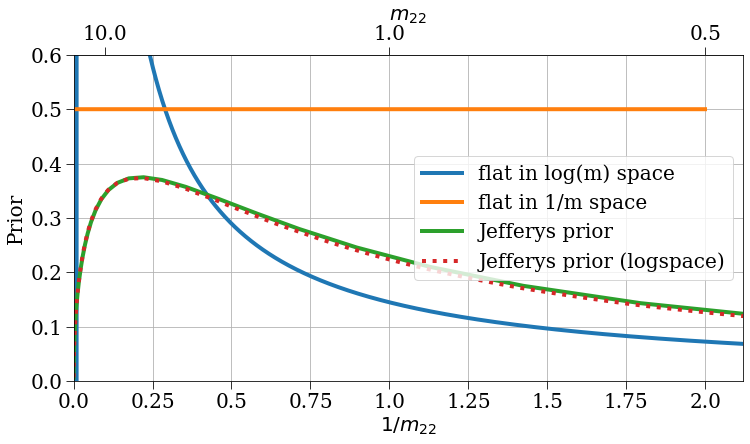

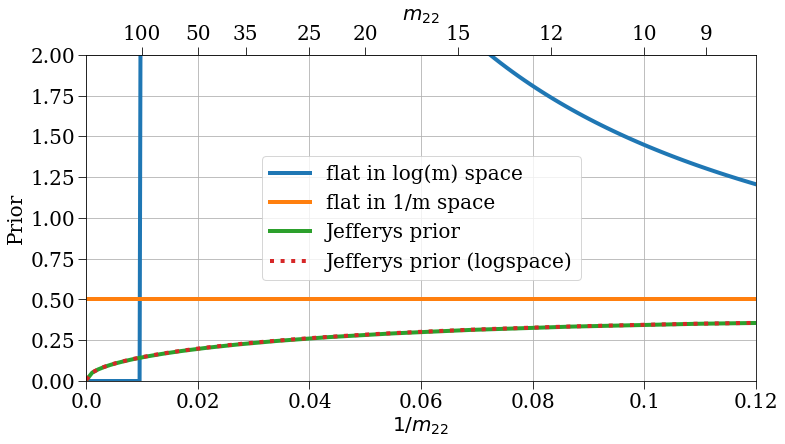

In [7]:
inv_m22 = np.linspace(1e-5,2.12,2000)
plt.figure(figsize=[12,6])
plt.plot(inv_m22, [log_prior(i) for i in inv_m22], label='flat in log(m) space')
plt.plot(inv_m22, [inv_prior(i) for i in inv_m22], label='flat in 1/m space')
plt.plot(inv_m22, [jeff_prior(i) for i in inv_m22], label='Jefferys prior')
plt.plot(inv_m22, [jeff_prior_in_log(i) for i in inv_m22], label='Jefferys prior (logspace)', ls=':')
plt.xlim(1e-5, 2.12)
plt.ylim(0,0.6)
plt.xlabel(r'$1/m_{22}$')
plt.ylabel('Prior')
ax1 = plt.gca()
locs, labels = plt.xticks()
plt.xticks(np.clip(locs,1e-5,np.inf), np.round(locs, 2))
def forward(x):
    return 1/x
ax2 = plt.gca().secondary_xaxis('top', functions=(forward, forward))
ax2.set_xticks([0.5, 1, 10])
ax2.set_xlabel(r'$m_{22}$')
plt.legend()
plt.xlim(1e-5, 2.12)
plt.figure(figsize=[12,6])
plt.plot(inv_m22, [log_prior(i) for i in inv_m22], label='flat in log(m) space')
plt.plot(inv_m22, [inv_prior(i) for i in inv_m22], label='flat in 1/m space')
plt.plot(inv_m22, [jeff_prior(i) for i in inv_m22], label='Jefferys prior')
plt.plot(inv_m22, [jeff_prior_in_log(i) for i in inv_m22], label='Jefferys prior (logspace)', ls=':')
plt.xlabel(r'$1/m_{22}$')
plt.ylabel('Prior')
plt.xlim(1e-5, 0.12)
plt.ylim(0,2)
plt.legend()
ax1 = plt.gca()
locs, labels = plt.xticks()
plt.xticks(np.clip(locs,1e-5,np.inf), np.round(locs, 2))
def forward(x):
    return 1/x
ax2 = plt.gca().secondary_xaxis('top', functions=(forward, forward))
ax2.set_xticks([9,10, 12, 15, 20, 25, 35, 50, 100])
ax2.set_xlabel(r'$m_{22}$')

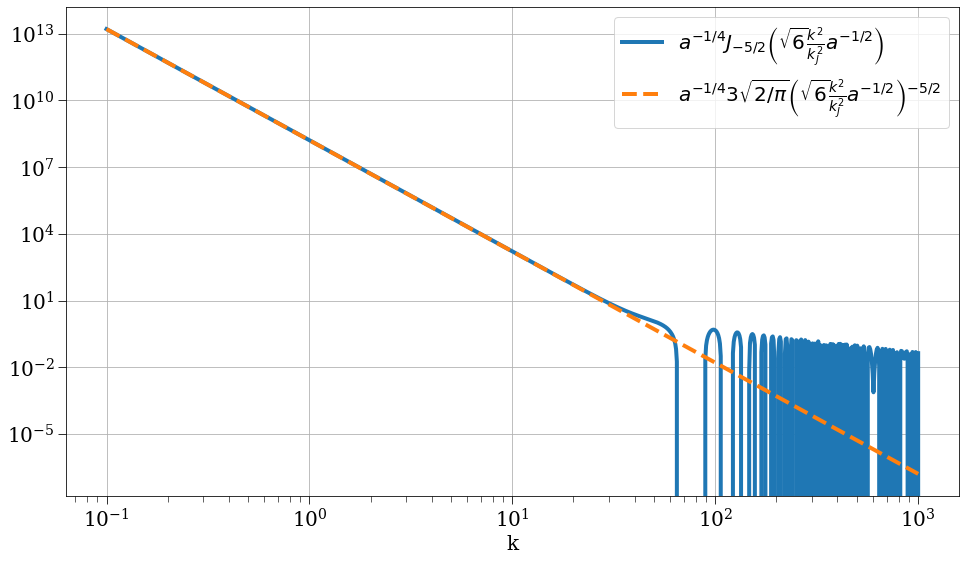

In [33]:
z = 10
a = 1/(1+z)
kvals = np.logspace(-1,3,1000)
z_norm = 20
delta_CDM_EQ = gf(z_norm)
plt.plot(kvals, [fdm_growth(z=z,k=k) for k in kvals], label=r'$a^{-1/4} J_{-5/2}\left(\sqrt{6} \frac{k^2}{k_J^2} a^{-1/2}\right)$')
plt.plot(kvals, [fdm_growth(z=z,k=k, taylor=1) for k in kvals], label=r'$a^{-1/4} 3\sqrt{2/\pi}  \left(\sqrt{6} \frac{k^2}{k_J^2} a^{-1/2}\right)^{-5/2}$', ls='--')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('k')
plt.legend()

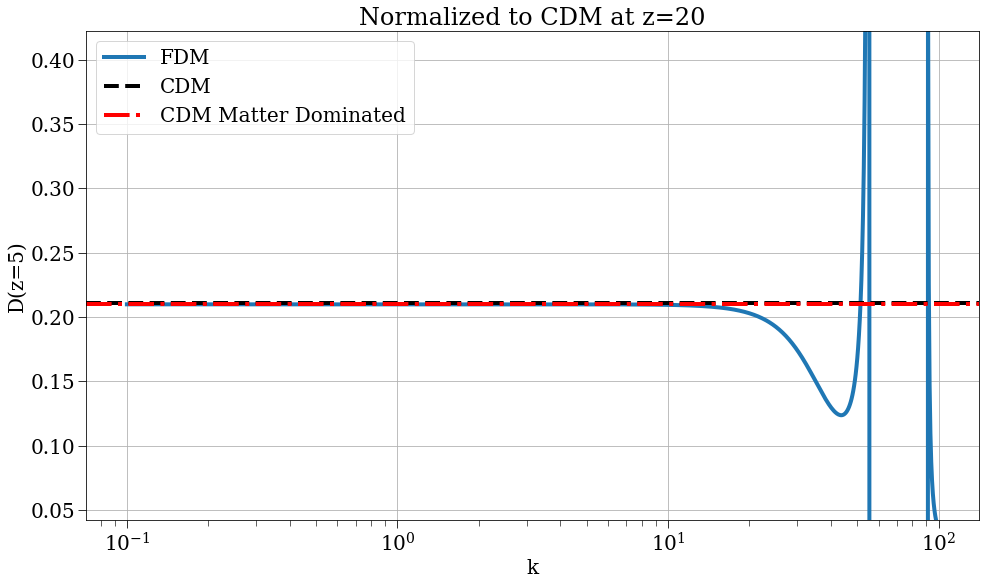

In [19]:
z = 5
a = 1/(1+z)
kvals = np.logspace(-1,2,1000)
z_norm = 20
delta_CDM_EQ = gf(z_norm)
normalization = np.array([fdm_growth(z=z_norm, k=k) for k in kvals]) / delta_CDM_EQ
plt.plot(kvals, [fdm_growth(z=z,k=k) for k in kvals]/normalization, label='FDM')
gfz = gf(z)
gfz2 = gf_matdom(z, z_norm=z_norm)
plt.axhline(y=gfz, color='k', ls='--', label='CDM')
plt.axhline(y=gfz2, color='red', ls='-.', label='CDM Matter Dominated')
# plt.axvline(x=xline/np.sqrt(a), ls='--',color='k')
#plt.axhline(y=1, ls='--',color='k')
#plt.yscale('log')
plt.xscale('log')
plt.title(f'Normalized to CDM at z={z_norm}')
plt.xlabel('k')
plt.ylabel(f'D(z={z})')
plt.ylim(gfz/5, gfz*2)
plt.legend()

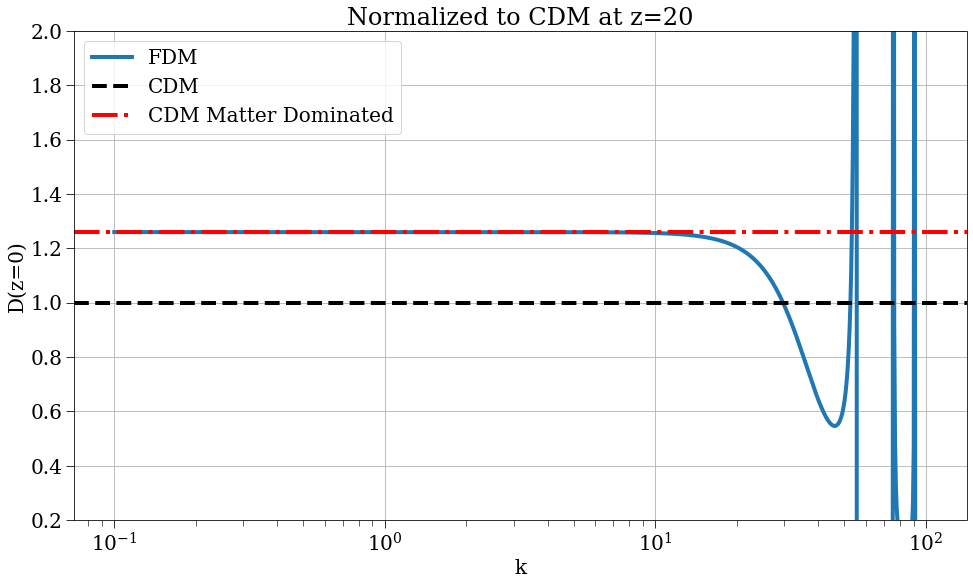

In [20]:
z = 0
a = 1/(1+z)
kvals = np.logspace(-1,2,1000)
z_norm = 20
delta_CDM_EQ = gf(z_norm)
normalization = np.array([fdm_growth(z=z_norm, k=k) for k in kvals]) / delta_CDM_EQ
plt.plot(kvals, [fdm_growth(z=z,k=k) for k in kvals]/normalization, label='FDM')
gfz = gf(z)
gfz2 = gf_matdom(z, z_norm=z_norm)
plt.axhline(y=gfz, color='k', ls='--', label='CDM')
plt.axhline(y=gfz2, color='red', ls='-.', label='CDM Matter Dominated')
# plt.axvline(x=xline/np.sqrt(a), ls='--',color='k')
#plt.axhline(y=1, ls='--',color='k')
#plt.yscale('log')
plt.xscale('log')
plt.title(f'Normalized to CDM at z={z_norm}')
plt.xlabel('k')
plt.ylabel(f'D(z={z})')
plt.ylim(gfz/5, gfz*2)
plt.legend()

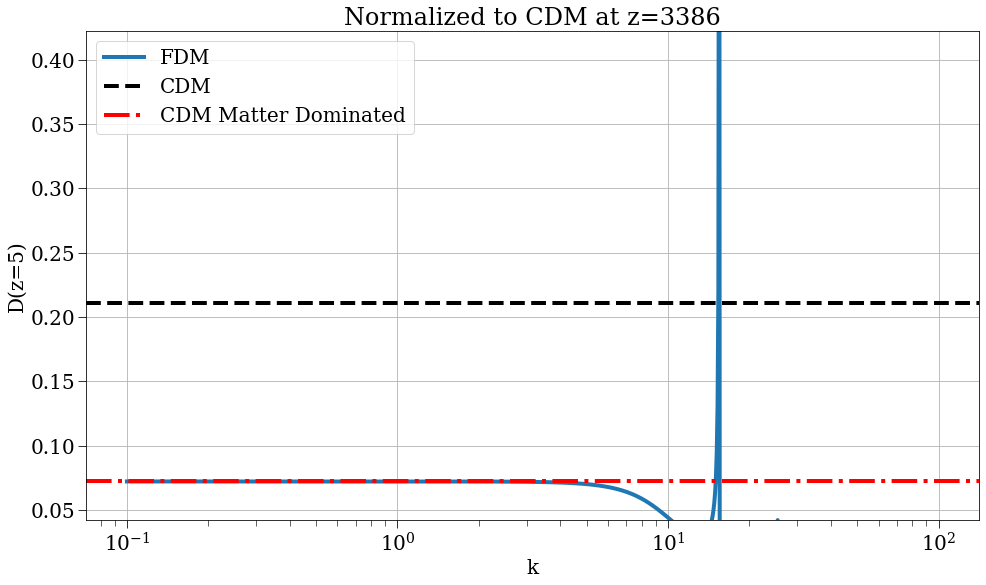

In [22]:
z = 5
a = 1/(1+z)
kvals = np.logspace(-1,2,1000)
z_norm = Z_EQ
delta_CDM_EQ = gf(z_norm)
normalization = np.array([fdm_growth(z=z_norm, k=k) for k in kvals]) / delta_CDM_EQ
plt.plot(kvals, [fdm_growth(z=z,k=k) for k in kvals]/normalization, label='FDM')
gfz = gf(z)
gfz2 = gf_matdom(z, z_norm=z_norm)
plt.axhline(y=gfz, color='k', ls='--', label='CDM')
plt.axhline(y=gfz2, color='red', ls='-.', label='CDM Matter Dominated')
# plt.axvline(x=xline/np.sqrt(a), ls='--',color='k')
#plt.axhline(y=1, ls='--',color='k')
#plt.yscale('log')
plt.xscale('log')
plt.title(f'Normalized to CDM at z={int(z_norm)}')
plt.xlabel('k')
plt.ylabel(f'D(z={z})')
plt.ylim(gfz/5, gfz*2)
plt.legend()

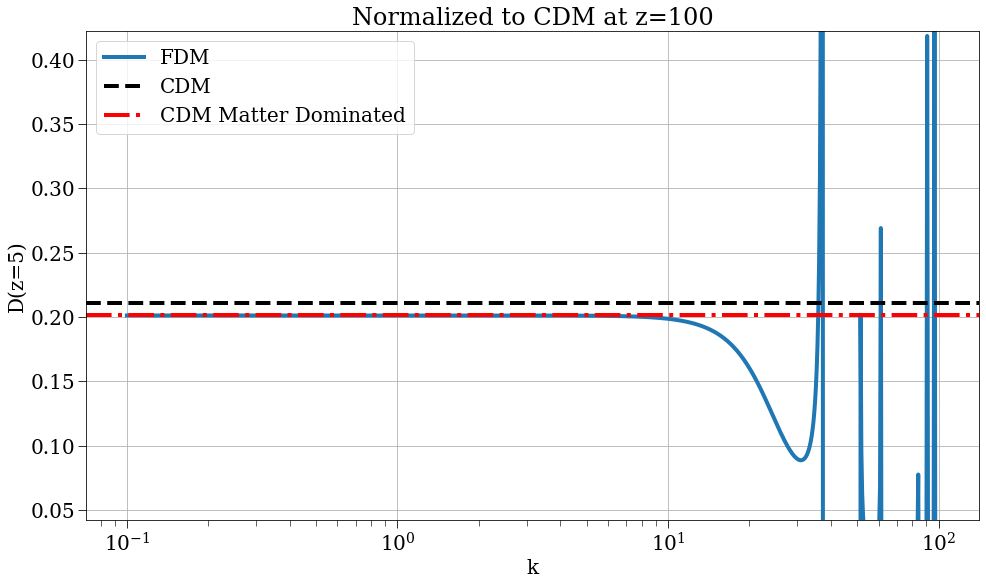

In [24]:
z = 5
a = 1/(1+z)
kvals = np.logspace(-1,2,1000)
z_norm = 100
delta_CDM_EQ = gf(z_norm)
normalization = np.array([fdm_growth(z=z_norm, k=k) for k in kvals]) / delta_CDM_EQ
plt.plot(kvals, [fdm_growth(z=z,k=k) for k in kvals]/normalization, label='FDM')
gfz = gf(z)
gfz2 = gf_matdom(z, z_norm=z_norm)
plt.axhline(y=gfz, color='k', ls='--', label='CDM')
plt.axhline(y=gfz2, color='red', ls='-.', label='CDM Matter Dominated')
# plt.axvline(x=xline/np.sqrt(a), ls='--',color='k')
#plt.axhline(y=1, ls='--',color='k')
#plt.yscale('log')
plt.xscale('log')
plt.title(f'Normalized to CDM at z={int(z_norm)}')
plt.xlabel('k')
plt.ylabel(f'D(z={z})')
plt.ylim(gfz/5, gfz*2)
plt.legend()